# Module 03 — Fractional Ornstein–Uhlenbeck Process

We model each stationary cointegration spread as

\[
dX_t = \kappa(\mu-X_t)dt+\sigma dB_t^H.
\]

The Hurst parameter \(H\) is now a parameter of the stochastic process itself rather than a separate trading indicator.

## Estimation sequence

1. Estimate \(H\) using second-order change-of-frequency variations.
2. Estimate \(\sigma\) from second-order variation conditional on \(H\).
3. Estimate \(\mu\) from the formation spread.
4. Estimate \(\kappa\) from the stationary fOU variance identity.
5. Save the fitted parameters for Module 04.

Only formation/training data should be used here.

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.fractional_OU import (
    estimate_fractional_ou,
    fit_pairs_fractional_ou,
    standardized_spread,
)

## 1. Load eligible pairs and training spreads

Change the paths below to your actual filenames.

In [2]:
cointegrated_pairs = pd.read_parquet("data/processed/cointegrated_pairs.parquet")
cointegrated_pairs["pair"] = (cointegrated_pairs["dependent"]+ "-"+ cointegrated_pairs["independent"])

with open("data/processed/spreads.pkl", "rb") as f:
    spreads = pickle.load(f)

print(f"cointegrated pairs: {len(cointegrated_pairs)}")
print(f"number of spreads: {len(spreads)}")
print(cointegrated_pairs.columns.tolist())
print(cointegrated_pairs.head())

print(type(spreads))
print(len(spreads))

list(spreads.keys())[:5]

missing = []

for _, row in cointegrated_pairs.iterrows():

    key = (
        row["dependent"],
        row["independent"]
    )

    if key not in spreads:
        missing.append(key)

print("Missing:", len(missing))
print(missing[:10])

cointegrated pairs: 446
number of spreads: 446
['dependent', 'independent', 'alpha', 'beta', 'adf', 'pvalue', 'pair']
  dependent independent     alpha      beta       adf    pvalue       pair
0       SHW          HD -0.580495  1.084491 -5.474267  0.000002     SHW-HD
1      ORCL         ETN  0.640542  0.742037 -4.993938  0.000023   ORCL-ETN
2      SPGI         ICE -1.358285  1.542537 -4.985110  0.000024   SPGI-ICE
3       ETN         JBL  1.246885  0.904839 -4.947990  0.000028    ETN-JBL
4      NDSN        ODFL  2.783512  0.528448 -4.928276  0.000031  NDSN-ODFL
<class 'dict'>
446
Missing: 0
[]


## 2. Fit one pair first

In [3]:
row = cointegrated_pairs.iloc[0]
pair = row["pair"]
dep = row["dependent"]
indep = row["independent"]

spread = spreads[(dep, indep)]
params = estimate_fractional_ou(spread)

print(pair)
print(params)

SHW-HD
FOUParameters(mu=-1.1245883890597607e-14, kappa=0.030470061929491365, sigma=0.015142195771467871, hurst=0.47986053151601293, variance=0.0032154356504426034, drift_half_life=22.748466418083055, n_obs=1759)


The `drift_half_life` is retained only as a characteristic drift timescale:

\[
HL_{drift}=\frac{\ln 2}{\kappa}.
\]

It is **not** the option DTE rule anymore. Module 04 obtains DTE from a convergence-probability target.

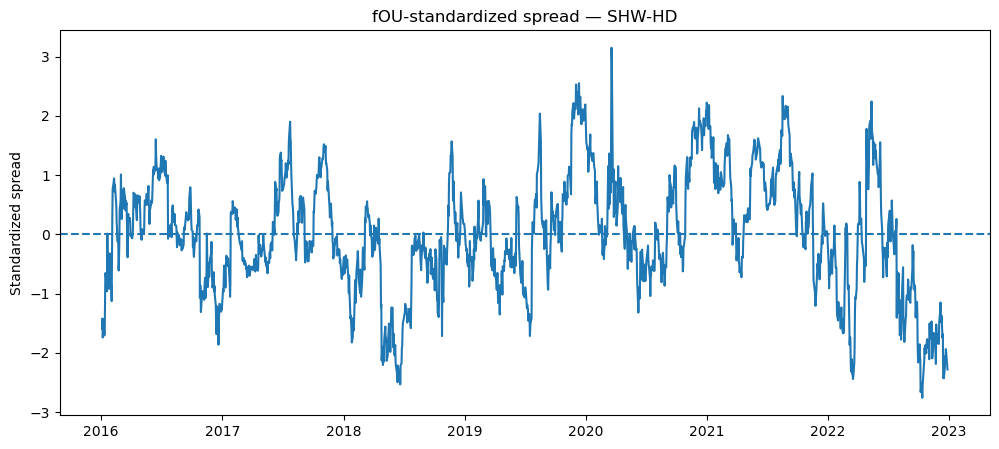

In [4]:
z = standardized_spread(
    spread,
    mu=params.mu,
    variance=params.variance,
)

plt.figure(figsize=(12,5))
plt.plot(z.index, z)
plt.axhline(0, linestyle="--")
plt.title(f"fOU-standardized spread — {pair}")
plt.ylabel("Standardized spread")
plt.show()

## 3. Fit all eligible pairs

In [5]:
fou_parameters = fit_pairs_fractional_ou(
    spreads=spreads,
    eligible_pairs=cointegrated_pairs,
)

fou_parameters

,pair,dependent,independent,mu,kappa,sigma,hurst,variance,drift_half_life,n_obs
0,PNW-WEC,PNW,WEC,-1.501370e-14,0.000103,0.011871,0.264904,0.008092,6714.068319,1759
1,PNW-KR,PNW,KR,-1.878353e-15,0.000107,0.014387,0.269687,0.012727,6469.036001,1759
2,PNW-CMS,PNW,CMS,2.728662e-15,0.000179,0.011136,0.283184,0.007313,3871.281240,1759
3,PNW-SO,PNW,SO,6.285415e-15,0.000145,0.011961,0.286059,0.010003,4775.155049,1759
4,LH-RVTY,LH,RVTY,-5.975386e-15,0.000494,0.014856,0.289831,0.008114,1402.410304,1759
...,...,...,...,...,...,...,...,...,...,...
441,EVRG-DTE,EVRG,DTE,1.448150e-15,0.037039,0.012280,0.595372,0.004184,18.713952,1759
442,RMD-PODD,RMD,PODD,3.382046e-15,0.063214,0.023849,0.609654,0.009179,10.965103,1759
443,WEC-DG,WEC,DG,-1.129941e-14,0.059075,0.016303,0.623453,0.005116,11.733433,1759
444,EVRG-FE,EVRG,FE,8.571755e-15,0.057531,0.014839,0.681655,0.006551,12.048183,1759


## 4. Diagnostics

The final selected pairs should remain in the anti-persistent region. Estimates pushed against the upper bound indicate only weak evidence of anti-persistence.

In [6]:
fou_parameters[[
    "pair", "hurst", "kappa", "sigma", "variance", "drift_half_life"
]].describe()


,hurst,kappa,sigma,variance,drift_half_life
count,446.000000,446.000000,446.000000,446.000000,446.000000
mean,0.468459,0.013621,0.016645,0.010986,147.363303
std,0.063366,0.009973,0.005373,0.012218,544.807489
min,0.264904,0.000103,0.001998,0.000056,7.556284
25%,0.432232,0.006978,0.013695,0.005652,37.610866
50%,0.467748,0.011715,0.015575,0.007922,59.166467
75%,0.511019,0.018430,0.018444,0.011628,99.336355
max,0.699142,0.091731,0.041148,0.159736,6714.068319


In [7]:
print(
    fou_parameters["hurst"]
    .describe(
        percentiles=[
            .05, .10, .25,
            .50,
            .75, .90, .95
        ]
    )
)

print(
    "\nH < 0.5:",
    (fou_parameters["hurst"] < 0.5).sum()
)

print(
    "H >= 0.5:",
    (fou_parameters["hurst"] >= 0.5).sum()
)

print(
    "\nCorrelation H-kappa:",
    fou_parameters[
        ["hurst", "kappa"]
    ].corr().iloc[0, 1]
)

print(
    "\nCorrelation H-half-life:",
    fou_parameters[
        ["hurst", "drift_half_life"]
    ].corr().iloc[0, 1]
)

count    446.000000
mean       0.468459
std        0.063366
min        0.264904
5%         0.358006
10%        0.392174
25%        0.432232
50%        0.467748
75%        0.511019
90%        0.547391
95%        0.565031
max        0.699142
Name: hurst, dtype: float64

H < 0.5: 309
H >= 0.5: 137

Correlation H-kappa: 0.803738519526074

Correlation H-half-life: -0.4390232385230252


In [8]:
fou_parameters[
    [
        "pair",
        "hurst",
        "kappa",
        "sigma",
        "variance",
        "drift_half_life",
    ]
].sort_values("hurst").head(20)

,pair,hurst,kappa,sigma,variance,drift_half_life
0,PNW-WEC,0.264904,0.000103,0.011871,0.008092,6714.068319
1,PNW-KR,0.269687,0.000107,0.014387,0.012727,6469.036001
2,PNW-CMS,0.283184,0.000179,0.011136,0.007313,3871.281240
3,PNW-SO,0.286059,0.000145,0.011961,0.010003,4775.155049
4,LH-RVTY,0.289831,0.000494,0.014856,0.008114,1402.410304
5,NWS-NWSA,0.297133,0.003319,0.004696,0.000293,208.864148
6,PNW-AEE,0.299202,0.000303,0.011531,0.007579,2291.102145
7,PRU-L,0.313080,0.001089,0.013539,0.005891,636.655524
8,DTE-PCG,0.320004,0.000654,0.019327,0.018329,1060.641446
9,NI-PCG,0.321192,0.000898,0.017014,0.011786,771.490328


In [9]:
fou_parameters[
    [
        "pair",
        "hurst",
        "kappa",
        "sigma",
        "variance",
        "drift_half_life",
    ]
].sort_values("hurst", ascending=False).head(20)

,pair,hurst,kappa,sigma,variance,drift_half_life
445,WELL-AVB,0.699142,0.091731,0.018862,0.006231,7.556284
444,EVRG-FE,0.681655,0.057531,0.014839,0.006551,12.048183
443,WEC-DG,0.623453,0.059075,0.016303,0.005116,11.733433
442,RMD-PODD,0.609654,0.063214,0.023849,0.009179,10.965103
441,EVRG-DTE,0.595372,0.037039,0.012280,0.004184,18.713952
440,KKR-NDAQ,0.593683,0.045433,0.022577,0.010955,15.256516
439,NDSN-ITW,0.589889,0.051449,0.017008,0.005223,13.472414
438,WELL-EQR,0.589124,0.034585,0.016704,0.008002,20.041927
437,AVGO-KLAC,0.586355,0.028901,0.017670,0.010816,23.983285
436,SYK-V,0.581774,0.035323,0.014111,0.005262,19.623301


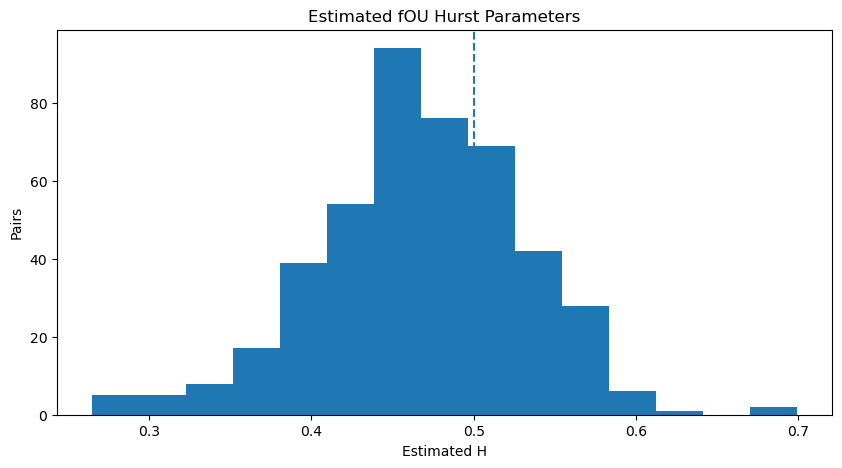

In [10]:
plt.figure(figsize=(10,5))
plt.hist(fou_parameters["hurst"], bins=15)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Estimated H")
plt.ylabel("Pairs")
plt.title("Estimated fOU Hurst Parameters")
plt.show()

In [11]:
eligible = (
    fou_parameters[
        (fou_parameters["hurst"] < 0.5)
        & (fou_parameters["kappa"] > 0)
        & np.isfinite(fou_parameters["kappa"])
        & np.isfinite(fou_parameters["sigma"])
        & np.isfinite(fou_parameters["drift_half_life"])
    ]
    .sort_values("drift_half_life")
    .copy()
)

top40 = eligible.head(40)

print(
    top40[
        [
            "pair",
            "hurst",
            "kappa",
            "sigma",
            "drift_half_life",
        ]
    ].to_string(index=False)
)

print("\nTop-40 summary:")
print(
    top40[
        [
            "hurst",
            "kappa",
            "sigma",
            "drift_half_life",
        ]
    ].describe()
)

     pair    hurst    kappa    sigma  drift_half_life
  MLM-VMC 0.480033 0.033820 0.014024        20.495399
   SHW-HD 0.479861 0.030470 0.015142        22.748466
   URI-MS 0.466323 0.025619 0.022751        27.055546
 ORCL-ETN 0.480991 0.024537 0.015696        28.248704
 SPGI-MCO 0.476892 0.024497 0.009739        28.295733
  PHM-NVR 0.487804 0.022499 0.016728        30.807372
 ETN-KLAC 0.495416 0.022089 0.016379        31.380244
  MAS-LEN 0.499331 0.021569 0.016999        32.135559
    V-ROP 0.467707 0.021548 0.014852        32.167630
  ABT-STE 0.487555 0.021089 0.014017        32.868084
 ETN-AVGO 0.496970 0.020884 0.017438        33.190885
  HLT-AXP 0.442941 0.020812 0.017825        33.305885
  PEP-HSY 0.452009 0.020260 0.010220        34.213011
 SHW-MSCI 0.498951 0.020202 0.015310        34.310240
    MTD-A 0.486443 0.020096 0.013155        34.491018
  SHW-DHI 0.478673 0.019970 0.019675        34.709941
 CRM-AMZN 0.486793 0.019871 0.018361        34.882131
  MCO-ZTS 0.470511 0.019777 

## 5. Save fitted parameters

In [18]:
fou_parameters.to_parquet("data/processed/fou_parameters.parquet", index=False)